## 5.6 Moteur de décision

Le moteur de décision est le composant central de BridgeGuard.
Il agrège les données de tous les modules (YOLOv8-seg, OpenCV, capteurs)
et produit une décision d'état système en temps réel.

**Entrées :**
- score_segmentation : score YOLOv8-seg (0→1)
- water_ratio : ratio eau OpenCV (0→1)
- ultrasonic : niveau eau HC-SR04 normalisé (0→1)
- flow : débit normalisé (0→1)
- rain : pluviométrie normalisée (0→1)
- bridge_clear : pont dégagé YOLOv8n (bool)

**Sorties :**
- state : état système (NORMAL/VIGILANCE/ALERT/CLOSED)
- score : score de risque global (0→1)
- commandes actionneurs : servomoteurs GPIO 11/27

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# CLASSE DecisionEngine — Moteur de décision BridgeGuard

class DecisionEngine:
    def __init__(self):
        # Seuils de décision
        self.threshold_vigilance = 0.40  # seuil vigilance
        self.threshold_alert     = 0.75  # seuil alerte critique
        self.threshold_safe      = 0.20  # seuil retour normal

        # État initial
        self.current_state = "NORMAL"

        # Historique pour analyse
        self.history_scores = []
        self.history_states = []
        self.history_times  = []

        # Poids agrégation
        self.weights = {
            "seg_score"  : 0.40,
            "water_ratio": 0.30,
            "ultrasonic" : 0.15,
            "flow"       : 0.10,
            "rain"       : 0.05
        }

    def compute_risk_score(self, seg_score, water_ratio,
                           ultrasonic, flow, rain):
        """
        Calcul du score de risque global par agrégation pondérée.
        Priorité aux modèles visuels (70%) + capteurs (30%).
        Retourne un score entre 0 (aucun risque) et 1 (risque maximal).
        """
        score = (self.weights["seg_score"]   * seg_score   +
                 self.weights["water_ratio"] * water_ratio +
                 self.weights["ultrasonic"]  * ultrasonic  +
                 self.weights["flow"]        * flow        +
                 self.weights["rain"]        * rain)
        return round(min(max(score, 0.0), 1.0), 4)

    def pivot_camera(self, direction):
        """
        Commande servomoteur 1 (GPIO 11) pour réorienter la caméra.
        direction='river'  → PWM 5%  → 0°  (surveillance rivière)
        direction='bridge' → PWM 10% → 90° (surveillance passerelle)
        """
        if direction == "river":
            print(" Caméra → Rivière (GPIO11 PWM 5% — 0°)")
        elif direction == "bridge":
            print(" Caméra → Passerelle (GPIO11 PWM 10% — 90°)")

    def close_barrier(self):
        """
        Commande servomoteur 2 (GPIO 27) → fermeture barrière.
        PWM 10% → 90° (barrière fermée)
        """
        print(" Barrière FERMÉE (GPIO27 PWM 10% — 90°)")

    def open_barrier(self):
        """
        Commande servomoteur 2 (GPIO 27) → ouverture barrière.
        PWM 5% → 0° (barrière ouverte)
        """
        print(" Barrière OUVERTE (GPIO27 PWM 5% — 0°)")

    def trigger_alert(self):
        """
        Déclenchement alertes : SMS Twilio + Dashboard rouge + V2I
        En production : appel API Supabase → webhook n8n → Twilio
        """
        print(" ALERTE déclenchée → SMS ingénieurs + V2I activé")

    def evaluate(self, seg_score, water_ratio,
                 ultrasonic, flow, rain, bridge_clear,
                 timestamp=None):
        """
        Fonction principale d'évaluation du risque et de transition d'états.
        Appelée à 1Hz en production sur le Raspberry Pi.
        """
        # Calcul score global
        score = self.compute_risk_score(
            seg_score, water_ratio, ultrasonic, flow, rain)

        previous_state = self.current_state

        # ── Machine à états ──────────────────────────────────
        if self.current_state == "NORMAL":
            if score > self.threshold_vigilance:
                self.current_state = "VIGILANCE"
                self.pivot_camera("bridge")

        elif self.current_state == "VIGILANCE":
            if score < self.threshold_vigilance:
                self.current_state = "NORMAL"
                self.pivot_camera("river")
            elif score > self.threshold_alert:
                self.current_state = "ALERT"
                self.trigger_alert()

        elif self.current_state == "ALERT":
            if bridge_clear:
                self.current_state = "CLOSED"
                self.close_barrier()
            else:
                print("Attente dégagement pont — véhicules détectés")

        elif self.current_state == "CLOSED":
            if score < self.threshold_safe:
                self.current_state = "NORMAL"
                self.open_barrier()
                self.pivot_camera("river")

        # Log transition
        if previous_state != self.current_state:
            print(f" Transition : {previous_state} → {self.current_state}")

        # Historique
        self.history_scores.append(score)
        self.history_states.append(self.current_state)
        if timestamp:
            self.history_times.append(timestamp)

        return self.current_state, score

print("Classe DecisionEngine définie !")

Classe DecisionEngine définie !


## Test du moteur de décision

On simule une séquence d'événements réaliste pour valider
le comportement du moteur de décision :

1. Niveau normal → état NORMAL
2. Montée progressive → VIGILANCE
3. Niveau critique → ALERTE
4. Pont dégagé → BARRIÈRE FERMÉE
5. Retour normal → RETOUR NORMAL

In [ ]:
# SIMULATION — Séquence d'inondation complète

engine = DecisionEngine()

# Séquence simulée : (seg_score, water_ratio, ultrasonic,
#                     flow, rain, bridge_clear, label)
sequence = [
    # Phase 1 — Normal
    (0.10, 0.08, 0.05, 0.10, 0.05, False, "Niveau normal"),
    (0.15, 0.12, 0.08, 0.12, 0.10, False, "Niveau normal"),
    (0.20, 0.18, 0.10, 0.15, 0.15, False, "Niveau normal"),

    # Phase 2 — Montée → Vigilance
    (0.35, 0.30, 0.25, 0.30, 0.40, False, "Montée eau"),
    (0.45, 0.42, 0.38, 0.40, 0.50, False, "→ VIGILANCE"),
    (0.50, 0.48, 0.42, 0.45, 0.55, False, "Vigilance"),

    # Phase 3 — Critique → Alerte
    (0.70, 0.65, 0.60, 0.65, 0.70, False, "Niveau critique"),
    (0.80, 0.75, 0.70, 0.72, 0.80, False, "→ ALERTE"),
    (0.85, 0.80, 0.75, 0.78, 0.85, False, "Alerte active"),

    # Phase 4 — Pont dégagé → Fermeture
    (0.85, 0.80, 0.75, 0.78, 0.85, False, "Véhicules présents"),
    (0.85, 0.80, 0.75, 0.78, 0.85, True,  "→ BARRIÈRE FERMÉE"),
    (0.85, 0.80, 0.75, 0.78, 0.85, True,  "Barrière fermée"),

    # Phase 5 — Retour normal
    (0.40, 0.35, 0.30, 0.35, 0.40, True,  "Baisse niveau"),
    (0.20, 0.15, 0.12, 0.15, 0.20, True,  "Retour normal"),
    (0.10, 0.08, 0.05, 0.08, 0.10, False, "→ NORMAL"),
]

print("SIMULATION — Moteur de décision BridgeGuard")

scores = []
states = []
labels = []

for i, (seg, ratio, ultra, flow, rain, clear, label) in enumerate(sequence):
    print(f"\nÉtape {i+1:02d} — {label}")
    state, score = engine.evaluate(seg, ratio, ultra,
                                   flow, rain, clear)
    print(f"  Score risque : {score:.3f} | État : {state}")
    scores.append(score)
    states.append(state)
    labels.append(label)

print("\n" + "=" * 55)
print("Simulation terminée !")

SIMULATION — Moteur de décision BridgeGuard

Étape 01 — Niveau normal
  Score risque : 0.084 | État : NORMAL

Étape 02 — Niveau normal
  Score risque : 0.125 | État : NORMAL

Étape 03 — Niveau normal
  Score risque : 0.172 | État : NORMAL

Étape 04 — Montée eau
  Score risque : 0.318 | État : NORMAL

Étape 05 — → VIGILANCE
 Caméra → Passerelle (GPIO11 PWM 10% — 90°)
 Transition : NORMAL → VIGILANCE
  Score risque : 0.428 | État : VIGILANCE

Étape 06 — Vigilance
  Score risque : 0.479 | État : VIGILANCE

Étape 07 — Niveau critique
  Score risque : 0.665 | État : VIGILANCE

Étape 08 — → ALERTE
 ALERTE déclenchée → SMS ingénieurs + V2I activé
 Transition : VIGILANCE → ALERT
  Score risque : 0.762 | État : ALERT

Étape 09 — Alerte active
Attente dégagement pont — véhicules détectés
  Score risque : 0.813 | État : ALERT

Étape 10 — Véhicules présents
Attente dégagement pont — véhicules détectés
  Score risque : 0.813 | État : ALERT

Étape 11 — → BARRIÈRE FERMÉE
 Barrière FERMÉE (GPIO27 PWM 

##Visualisation — Évolution du score et des états

On visualise l'évolution du score de risque et les transitions
d'états pendant la simulation pour valider le comportement
du moteur de décision.

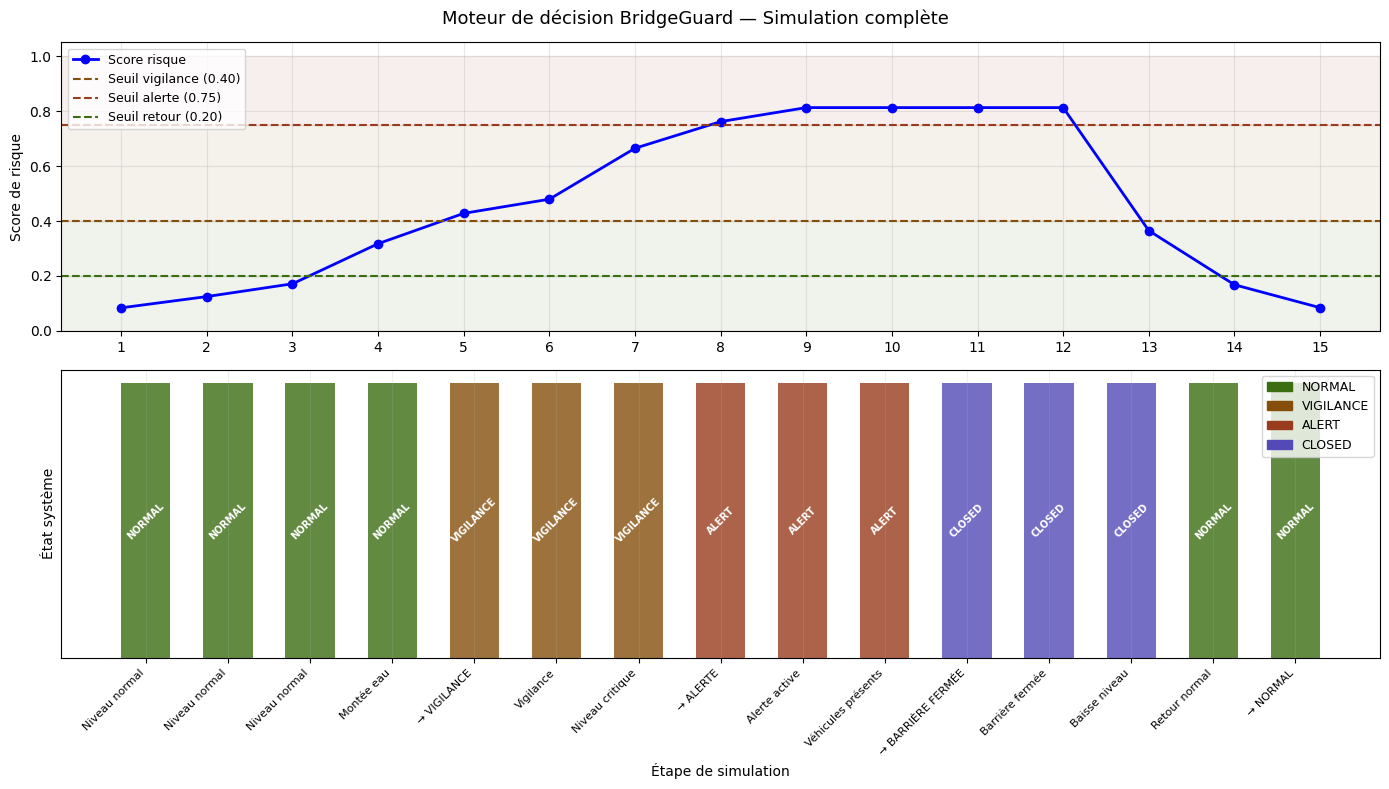

Visualisation sauvegardée !


In [ ]:
# VISUALISATION — Score de risque + États

state_colors = {
    "NORMAL"    : "#3B6D11",
    "VIGILANCE" : "#854F0B",
    "ALERT"     : "#993C1D",
    "CLOSED"    : "#534AB7"
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Moteur de décision BridgeGuard — Simulation complète",
             fontsize=13)

# ── Graphe 1 : Score de risque ────────────────────
steps = list(range(1, len(scores) + 1))
ax1.plot(steps, scores, "b-o", linewidth=2,
         markersize=6, label="Score risque")
ax1.axhline(y=0.40, color="#854F0B", linestyle="--",
            linewidth=1.5, label="Seuil vigilance (0.40)")
ax1.axhline(y=0.75, color="#993C1D", linestyle="--",
            linewidth=1.5, label="Seuil alerte (0.75)")
ax1.axhline(y=0.20, color="#3B6D11", linestyle="--",
            linewidth=1.5, label="Seuil retour (0.20)")

# Zones colorées
ax1.axhspan(0,    0.20, alpha=0.08, color="#3B6D11")
ax1.axhspan(0.20, 0.40, alpha=0.08, color="#3B6D11")
ax1.axhspan(0.40, 0.75, alpha=0.08, color="#854F0B")
ax1.axhspan(0.75, 1.00, alpha=0.08, color="#993C1D")

ax1.set_ylabel("Score de risque")
ax1.set_ylim(0, 1.05)
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(steps)

# ── Graphe 2 : États ─────────────────────────────
state_map = {"NORMAL": 0, "VIGILANCE": 1,
             "ALERT": 2, "CLOSED": 3}
state_vals = [state_map[s] for s in states]
colors     = [state_colors[s] for s in states]

ax2.bar(steps, [1]*len(states), color=colors,
        alpha=0.8, width=0.6)

for i, (s, l) in enumerate(zip(states, labels)):
    ax2.text(i+1, 0.5, s, ha="center", va="center",
             fontsize=7, color="white", fontweight="bold",
             rotation=45)

patches = [mpatches.Patch(color=c, label=s)
           for s, c in state_colors.items()]
ax2.legend(handles=patches, loc="upper right", fontsize=9)
ax2.set_ylabel("État système")
ax2.set_xlabel("Étape de simulation")
ax2.set_yticks([])
ax2.set_xticks(steps)
ax2.set_xticklabels(labels, rotation=45,
                    ha="right", fontsize=8)
ax2.grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig("decision_engine_simulation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Visualisation sauvegardée !")